LangChain已经能帮助我们开发智能体、RAG系统了，为什么还要学习LangGraph呢？


要明白这个问题，我们需要先弄清楚LangGraph到底能做什么。

让我们从AI应用的发展过程谈起。

## 1. AI应用的发展

### 1.1 简单LLM应用

在早期，AI应用就是简单的调用LLM：
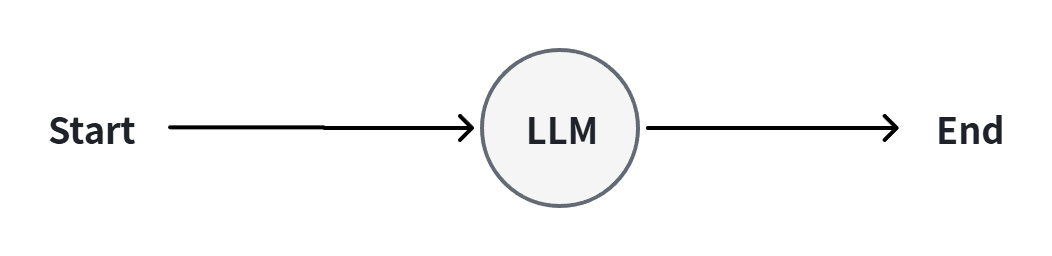
这时候的AI应用能力有限：
- 无法调用工具
- 无法访问外部数据
- 无法实现复杂多步骤任务

### 1.2 链式LLM应用（Chain）
为了增强LLM应用的能力，人们开始自定义程序执行流程，添加额外的步骤：
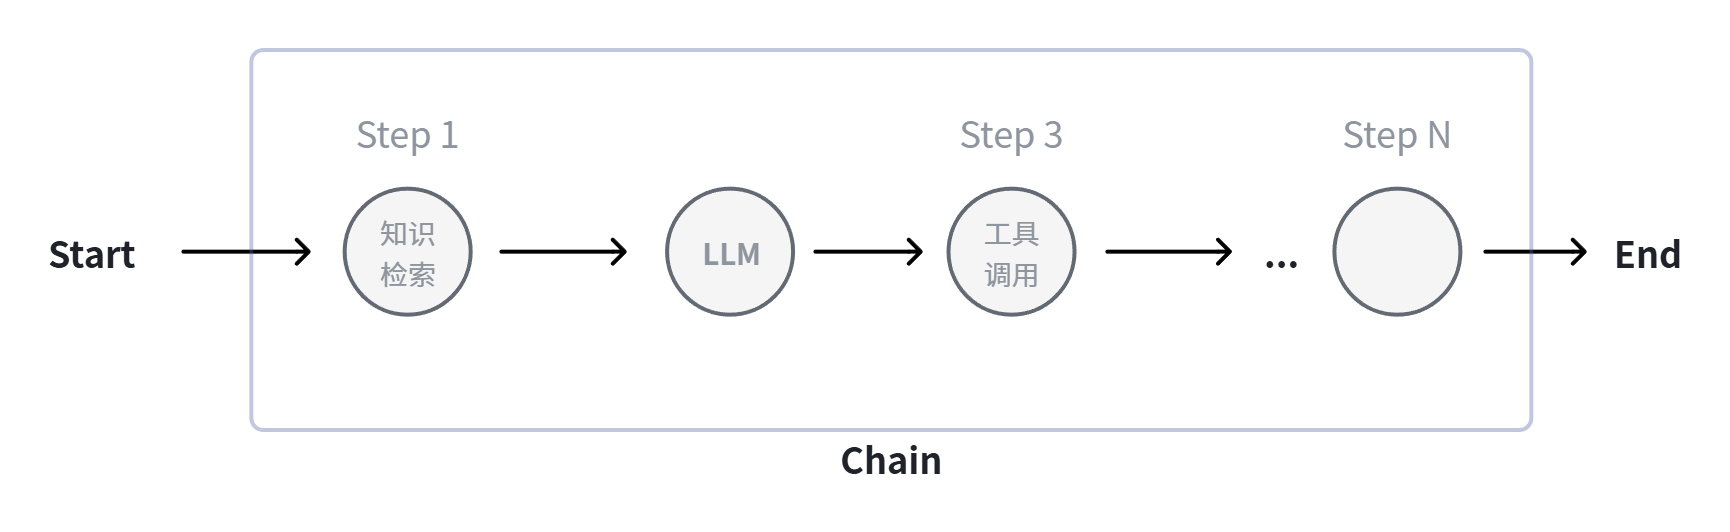
例如，在调用LLM前加入知识检索（retrieval），在模型调用之后加入工具调用（tool calls），此时整个由程序控制的工作流就形成了一个链条（Chain）。早期的LangChain也就是基于这种理念设计，这也是LangChain名字的由来。

这种人工定制的工作流特点是稳定可靠（Reliable），你不管执行多少次，流程一定是这样，不会出现意外情况。但是它缺乏自主智能（Agentic），距离真正的智能体相差甚远。

### 1.3 智能体（Agent）
所谓的智能体，就是指应用的执行工作流应该由LLM来决定，也就是让AI来自主规划工作流。
例如，由LLM来决定接下来应该执行Step 2 还是 Step 3：
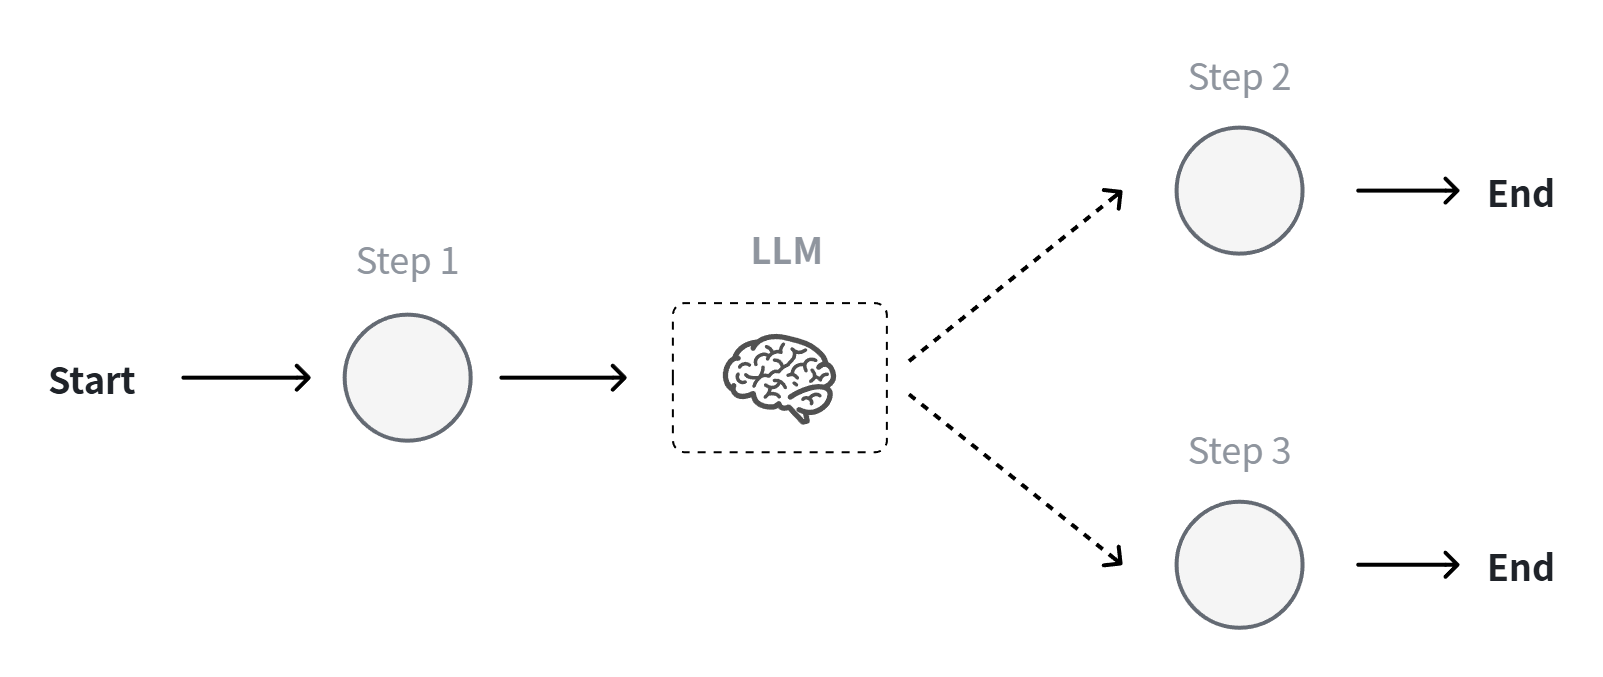
甚至，完全由LLM自主决定所有的执行流程：
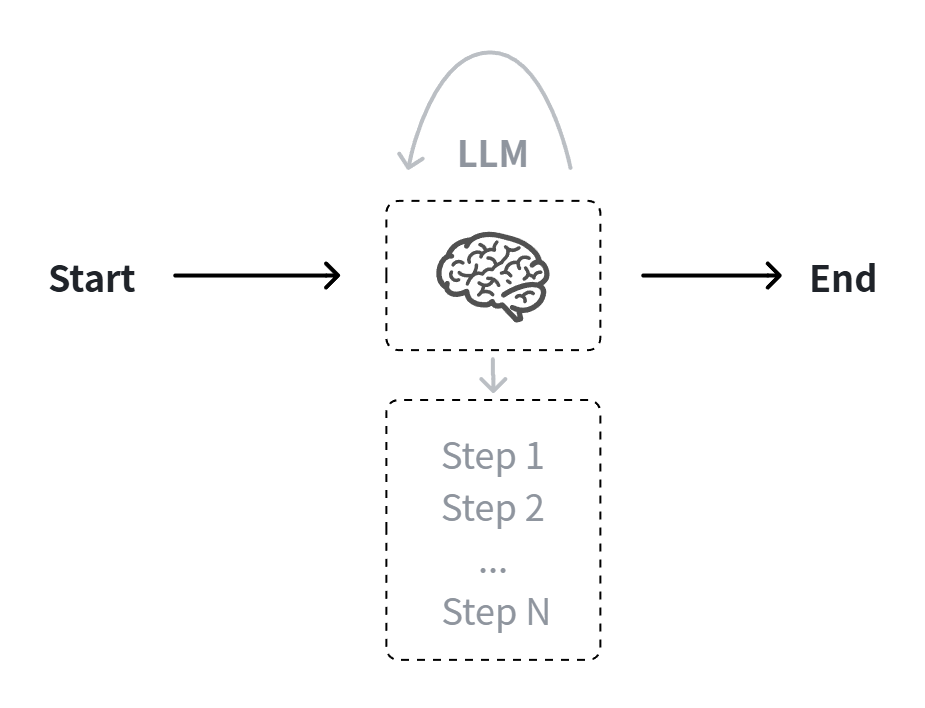

### 1.4 稳定度与自主控制力
虽然都是Agent，但上面的两个例子恰好是Agent的两个极端，或者说是LLM对应用控制能力的两个极端：
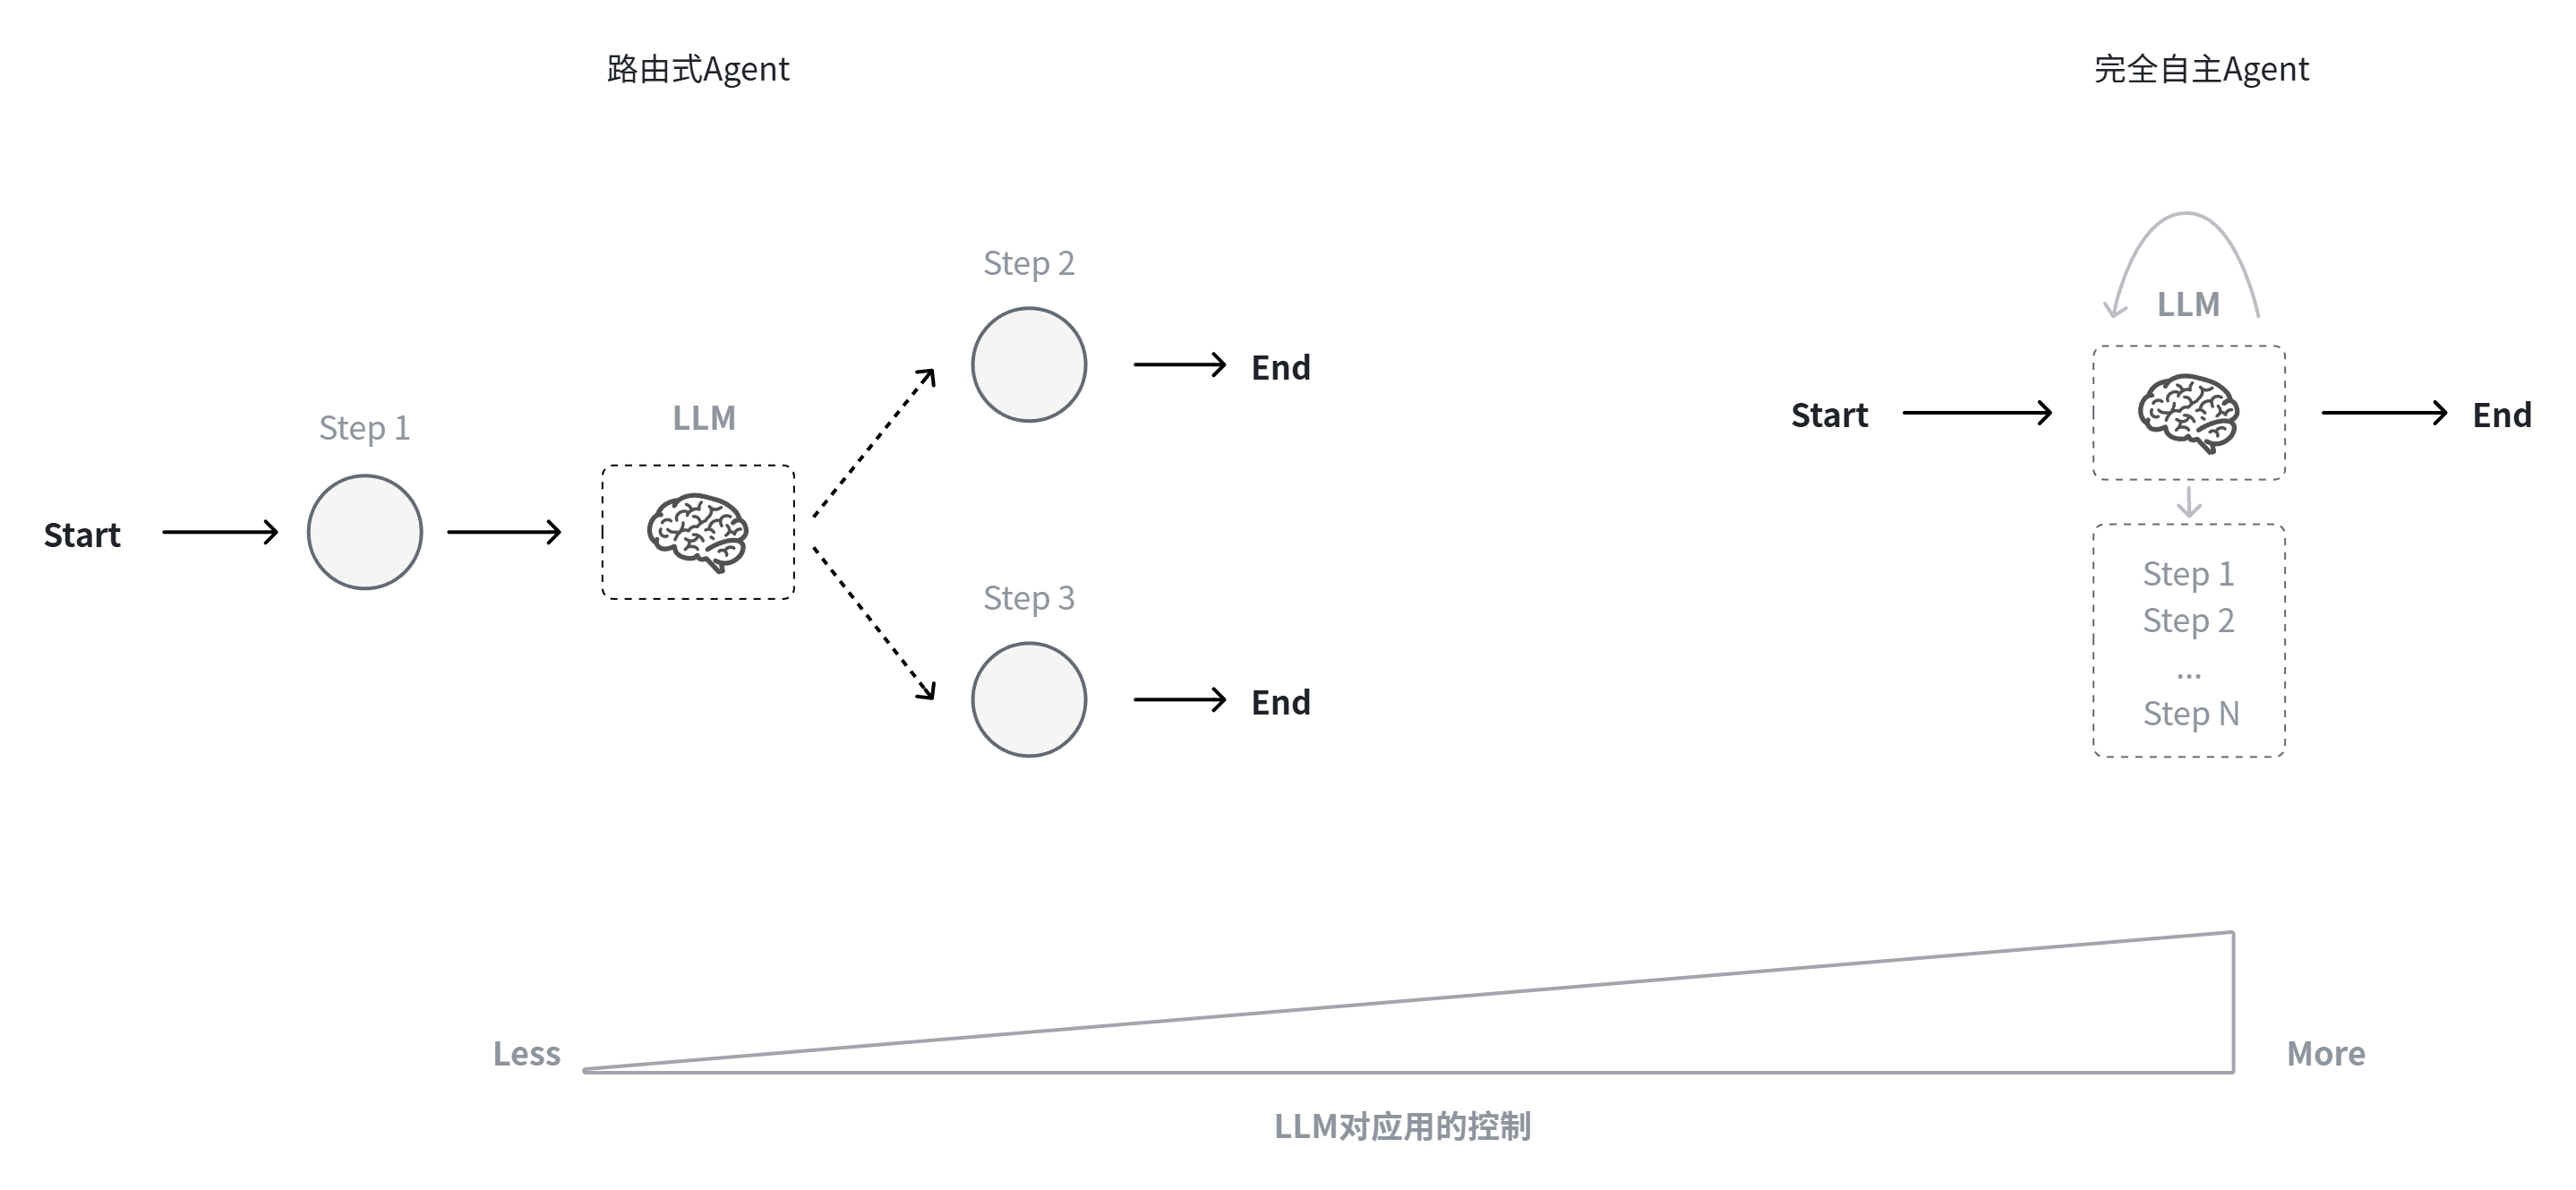
但是，Agent的自主控制能力与稳定程度之间是对立的两端，通常来说，LLM自主控制的越多，应用的稳定程度就会越小：
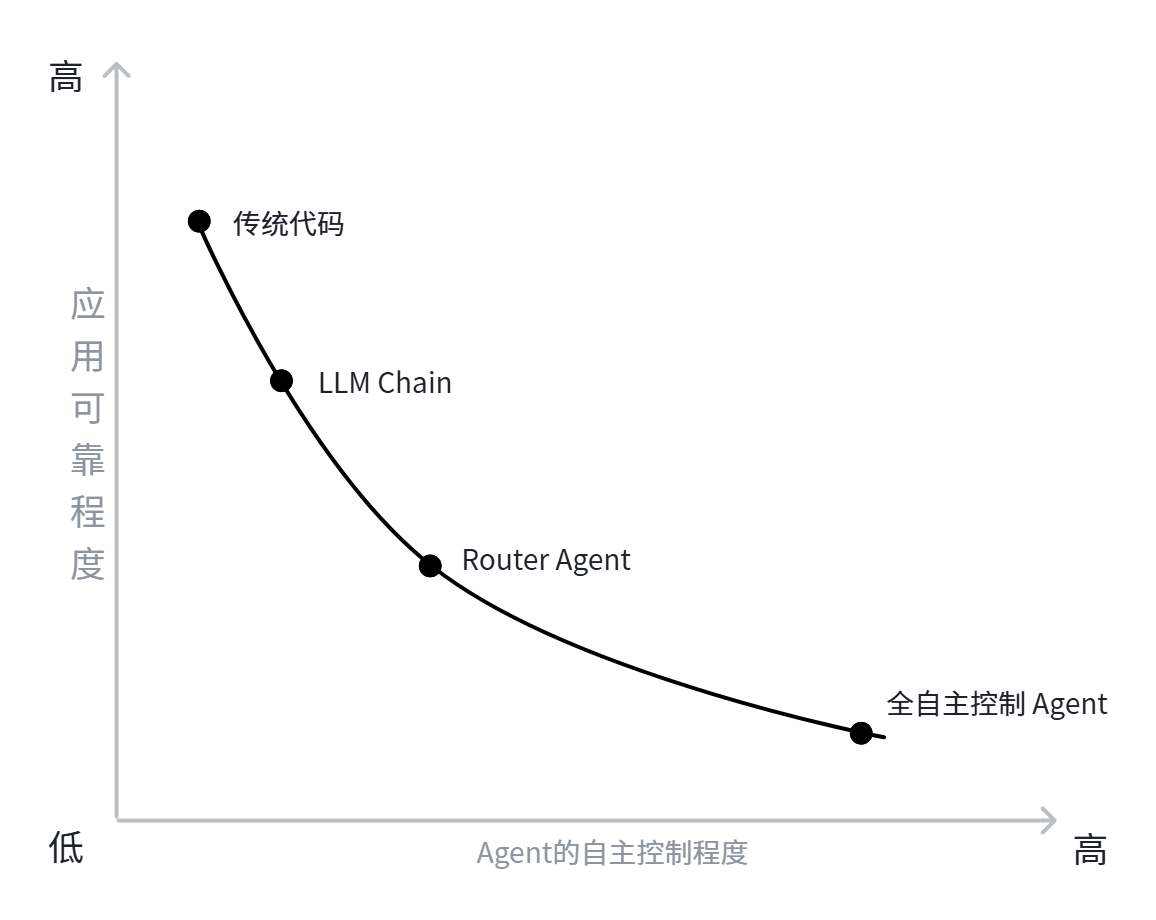
所以，通常来说，我们只能在可靠度和自主控制程度之间选择一个平衡点。

## 2. LangGraph的作用
LangGraph的作用就是在保持Agent的自主控制程度不变的同时，提高Agent的稳定程度：
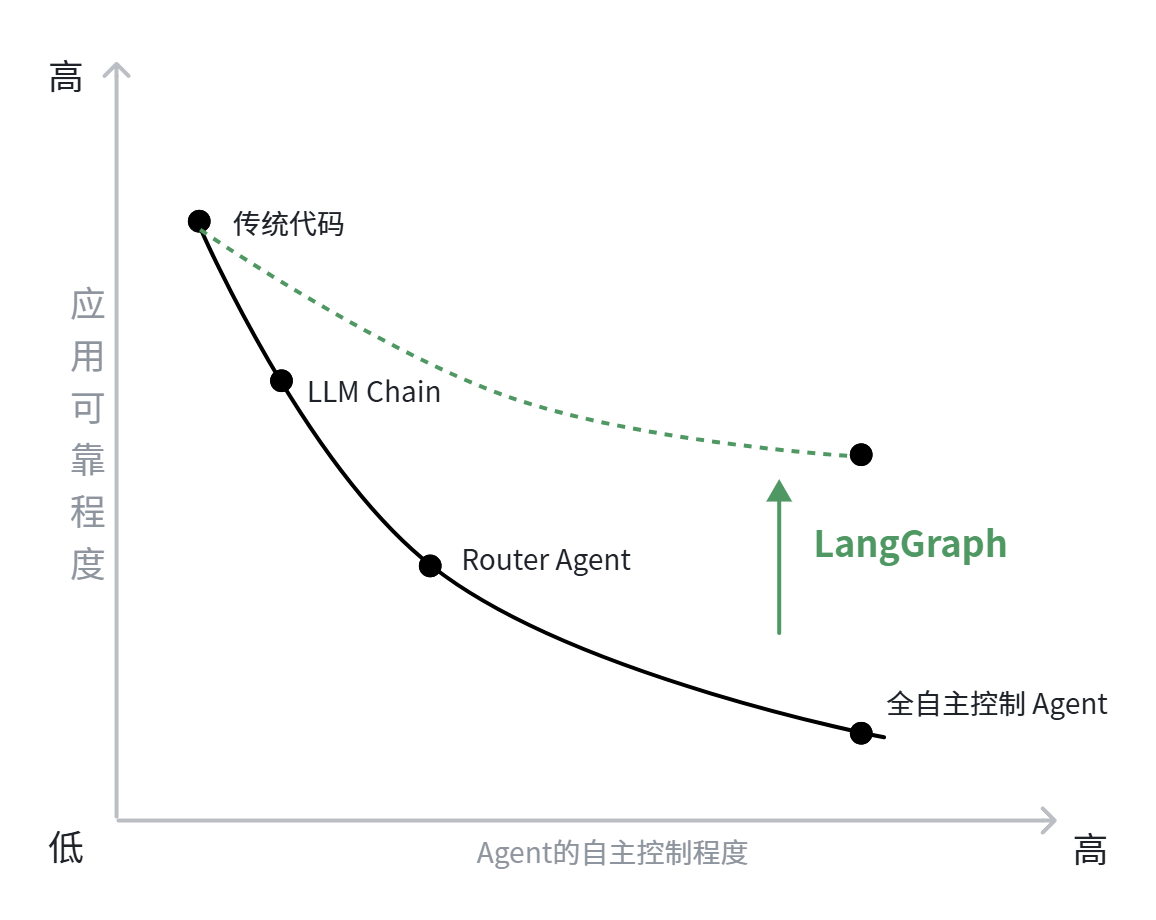

### 2.1 认识LangGraph
简单来说，LangGraph允许你自己定义Agent的工作流（WorkFlow）中的每一个节点（Node）：
- 需要稳定性的节点，就用传统编程控制
- 需要LLM自主控制的，就交给LLM

并且，整个工作流不再是一条直线运行的链（Chain），而是一个像真正工作流那样有分支、有循环的图（Graph）。

在LangGraph中，工作流由3个基本的要素组成：
- 节点（Node）：即工作流中的关键工作代码，可以是工具调用、知识检索、LLM调用
- 边（Edge）：也可以理解为线，就是把各个节点连接起来的路径，是控制工作流走向的关键
- 状态（State）：整个工作流中流转的数据
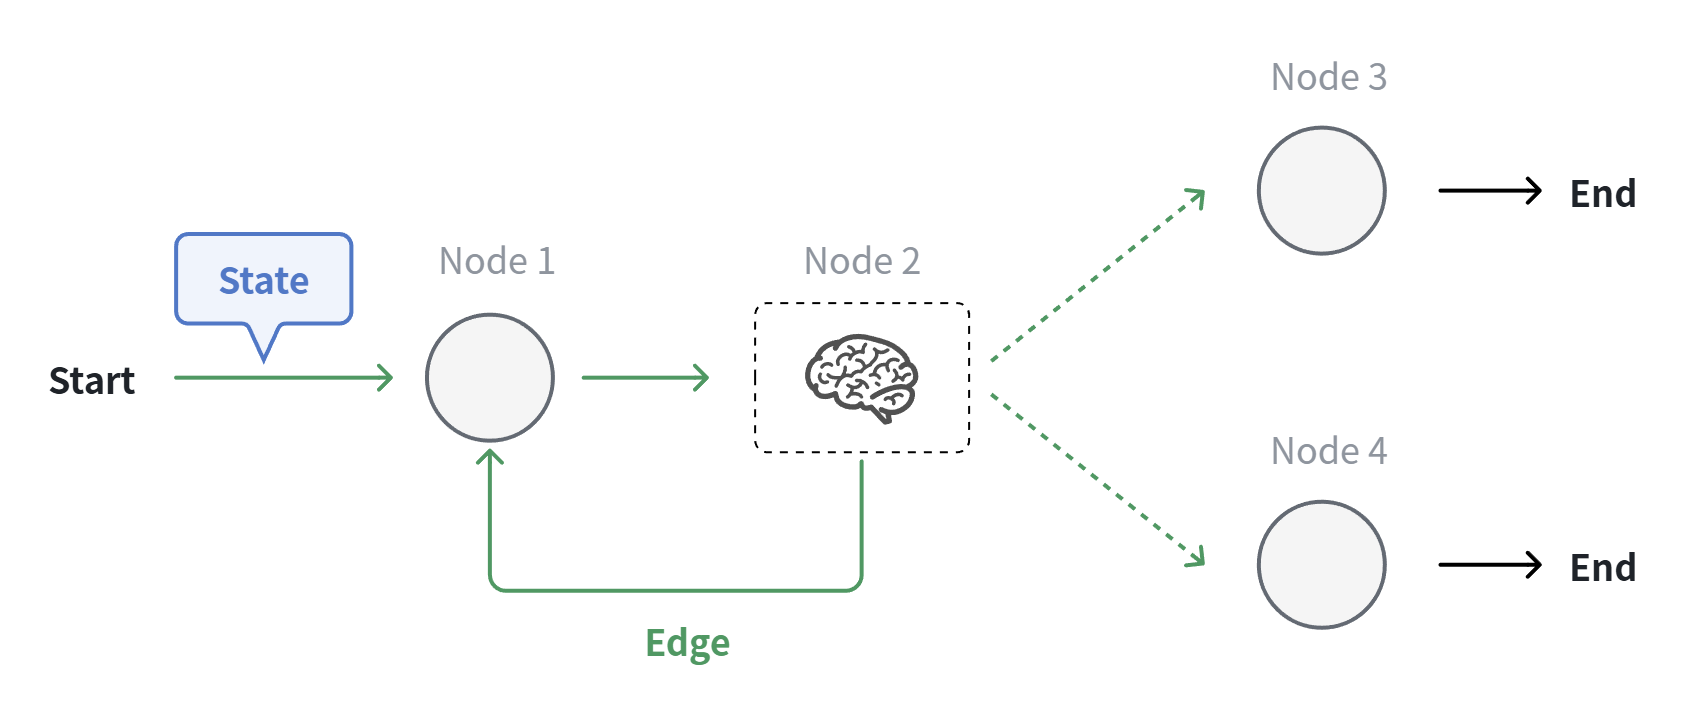
为了提高应用的运行的稳定程度，LangGraph为节点运行提供了Checkpointer功能，应用运行到每个节点（Node）都会形成检查点（Checkpoint），我们可以方便的跳转到任意checkpoint，这样一来应用就具备了三大功能：
- 故障恢复：即便是程序异常中止，也可以随时恢复到失败节点继续执行。
- 人机交互：在程序运行中可以暂停工作流，在关键节点允许人工介入，得到人工确认后恢复执行，进一步提高程序的可靠性。
- 持久记忆：由于Checkpointer可以持久化存储，能方便的拿到历史信息，因此应用还具备了记忆功能。

### 2.2 LangGraph与LangChain
看完上面的介绍，你是不是觉得这些功能似曾相识啊？

没错，在我们之前学习的LangChain开发中就有这些能力：
- Memory
- HITL
- ...

这是因为，自从LangChain的1.0版本以后，底层的Chain模式已经逐渐废弃，而是彻底的投入了Graph的怀抱。
LangChain 1.x之后的版本中，Agent的底层实现已经全部替换为基于LangGraph了！

不过，两者的定位完全不同：
- LangChain：便捷开发AI应用的框架，提供了开发AI应用的各种统一API
  - 统一的LLM调用
  - 统一的Embedding Model调用
  - 统一的Vector Store调用
  - ...
- LangGraph: 工作流编排框架，提供了完善的工作流编排工具
  - 基于Node和Edge的工作流编排
  - 基于State的工作流数据传输
  - 基于Checkpointer的数据持久化

总结一下：
- LangGraph关注的是工作流的编排，你的工作流甚至可以完全与LLM无关，与Agent无关。如果你利用LangGraph开发Agent，可以自由的控制Agent工作流中的每一个细节
  - 优点：自由度更高。
  - 缺点：比较繁琐
  - 场景：需要完全控制Agent工作流程和细节，或者复杂Agent工作流的情况
- LangChain则是提供的统一API，底层基于LangGraph实现Agent，简化了Agent的开发。
  - 优点：简化Agent开发
  - 确定：灵活度不如LangGraph
  - 场景：简单的LLM调用，或者快捷的Agent开发


掌握了LangGraph，你就掌握了开发复杂度高、可靠性高的Agent的能力，迈入了高级AI应用开发工程师的门槛。

接下来，我们就正式开始学习LangGraph，我们会分为以下几个部分：
1. LangGraph的基本概念和快速入门
2. LangGraph中常见的WorkFlow形式
3. 培养LangGraph思维模式